# Adversarial Forecasting: A GAN-Based Framework for Time-Series Imputation and Weather Prediction

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Melvin0163/Adversarial-Forecasting-A-GAN-Based-Framework-for-Time-Series-Imputation-and-Weather-Prediction/blob/main/Adversarial_Forecasting_GAN.ipynb)

**Study site:** Chennai, India (13.08° N, 80.23° E) · **Data:** ERA5-Land daily reanalysis, 1950–2025, six surface variables · **Target:** 2 m air temperature · **Framework:** TensorFlow / Keras

This notebook applies GAN variants to two tasks on daily weather data:

1. **Imputation:** filling values missing from the six-variable daily record.
2. **Forecasting:** predicting the next 7 days of temperature.

It tests the claim that a **unified, shared GAN architecture** (one generator for both tasks) is an optimized way to handle both, compared with a **Simple GAN** approach that trains a separate GAN for each task. "Optimized" is assessed on three criteria: accuracy, number of parameters and training time.

| Model | Generator | Adversary | Trained on | Evaluated on |
|---|---|---|---|---|
| **Shared GAN** | BiLSTM generator over 30-day blocks (shared architecture) | GAIN-style point-wise discriminator (binary cross-entropy) | imputation | imputation and forecasting |
| **Shared WGAN-GP** | same generator architecture | block-level Wasserstein critic with gradient penalty | imputation, with re-masking of observed values | imputation and forecasting |
| **Simple GAN** | one generator per task | GAIN-style discriminator (imputation); conditional discriminator (forecasting) | each task separately | the task it was trained for |

Only GAN variants are compared; no non-GAN baseline is included.

**Contents**
1. Data: ERA5-Land via Google Earth Engine
2. Data utilities: missingness, indicator, blocks, split
3. Model architectures
4. Shared GAN training
5. Shared WGAN-GP training
6. Shared models: data preparation, training and imputation results
7. Simple GAN: separate imputation and forecasting networks
8. Shared models as forecasters
9. Comparison: accuracy, parameters and training time
10. Temporal maps of the imputed temperatures
11. Results
12. Notes, changes from the original notebook, and references

## 1. Data: ERA5-Land via Google Earth Engine

Daily aggregates from **ERA5-Land** (`ECMWF/ERA5_LAND/DAILY_AGGR`), read at the grid cell that contains Chennai (80.23° E, 13.08° N), from 1950-01-02 to 2025-12-30 (27,757 days). ERA5-Land has no gaps, so missing values are created artificially (Section 2) and the removed values serve as ground truth.

| Column | Unit | Daily statistic |
|---|---|---|
| `temp` (2 m air temperature, target) | °C (converted from K) | mean |
| `surface_pressure` | Pa | mean |
| `total_precipitation_sum` | m | total |
| `dewpoint_temperature_2m` | K | mean |
| `u_component_of_wind_10m`, `v_component_of_wind_10m` | m s⁻¹ | mean |

The cell below makes sure that `data/era5_chennai_1950_2025.csv` exists. It uses the first available source: the local file (present in a clone of the repository), the copy in the GitHub repository (downloaded automatically, for example in Colab), or a fresh extraction from Earth Engine with `extract_era5_land()`. The last option needs a Google Cloud project with the Earth Engine API enabled; set `GEE_PROJECT` first.

In [1]:
import subprocess
import sys
from pathlib import Path

import pandas as pd

GEE_PROJECT = "your-gee-project-id"   # <-- only needed to re-extract the data from Earth Engine
LON, LAT = 80.23, 13.08                # Chennai
START_DATE, END_DATE = "1950-01-01", "2025-12-31"
ERA5_BANDS = ["temperature_2m", "surface_pressure", "total_precipitation_sum",
              "dewpoint_temperature_2m", "u_component_of_wind_10m", "v_component_of_wind_10m"]
DATA_CSV = Path("data/era5_chennai_1950_2025.csv")
DATA_URL = ("https://raw.githubusercontent.com/Melvin0163/Adversarial-Forecasting-A-GAN-Based-Framework-for-"
            "Time-Series-Imputation-and-Weather-Prediction/main/data/era5_chennai_1950_2025.csv")


def extract_era5_land(project, lon, lat, start, end):
    """Download the daily ERA5-Land aggregates at one point from Google Earth Engine."""
    if project == "your-gee-project-id":
        raise ValueError("Set GEE_PROJECT to your Earth Engine-enabled Google Cloud project, "
                         f"or place the extracted CSV at {DATA_CSV}.")
    try:
        import ee
        import geemap
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "earthengine-api", "geemap"])
        import ee
        import geemap

    ee.Authenticate()
    ee.Initialize(project=project)

    point = ee.Geometry.Point([lon, lat])
    era5 = (ee.ImageCollection("ECMWF/ERA5_LAND/DAILY_AGGR")
            .filterDate(start, end)
            .select(ERA5_BANDS))

    def to_feature(image):
        values = image.reduceRegion(ee.Reducer.first(), point, 1000)
        return ee.Feature(None, values.set("time", image.date().millis()))

    raw = geemap.ee_to_df(ee.FeatureCollection(era5.map(to_feature)))   # a few minutes for ~76 years
    raw["date"] = pd.to_datetime(raw["time"], unit="ms")
    raw["temp"] = raw["temperature_2m"] - 273.15                         # Kelvin -> Celsius
    return raw.sort_values("date").reset_index(drop=True)[["date", "temp"] + ERA5_BANDS[1:]]


DATA_CSV.parent.mkdir(parents=True, exist_ok=True)
if DATA_CSV.exists():
    source = "local copy"
else:
    try:
        pd.read_csv(DATA_URL).to_csv(DATA_CSV, index=False)
        source = "copy in the GitHub repository"
    except OSError as err:
        print(f"Repository copy not reachable ({err}); extracting from Earth Engine instead")
        extract_era5_land(GEE_PROJECT, LON, LAT, START_DATE, END_DATE).to_csv(DATA_CSV, index=False)
        source = "Google Earth Engine"
print(f"Data file ready: {DATA_CSV} (source: {source})")

Data file ready: data/era5_chennai_1950_2025.csv (source: local copy)


## 2. Data utilities

The functions below prepare the data for all models.

* `load_data` reads the CSV, sorts it by date and keeps the six variables.
* `inject_missing` removes values artificially, independently for each variable: 10 % of the days at random (single points) and about 10 % more as contiguous runs of 3 to 10 days. With seed 42 this removes 18.5 % of all values. It returns the data with the removed values set to NaN, and a mask (1 = removed).
* `make_indicator` turns the mask into missing-value indicator columns (1 = missing, 0 = observed).
* `build_blocks` cuts the series into non-overlapping 30-day blocks. The model input of each block concatenates the zero-filled values and the indicator, giving shape (blocks, 30, 12). The true values are kept for scoring.
* `chronological_split` assigns the first 70 % of the blocks to training, the next 15 % to validation and the last 15 % to testing, so every test block lies after every training block.

In [2]:
import numpy as np
import pandas as pd

FEATURES = [
    "temp",  # y (target)
    "surface_pressure",
    "total_precipitation_sum",
    "dewpoint_temperature_2m",
    "u_component_of_wind_10m",
    "v_component_of_wind_10m",
]
TARGET = "temp"
BLOCK_LEN = 30


def load_data(path):
    df = pd.read_csv(path)
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").reset_index(drop=True)
    return df[["date"] + FEATURES]


def inject_missing(df, rng, random_frac=0.10, block_frac=0.10,
                    block_len_range=(3, 10)):
    """
    Mix of random-wise (MCAR, scattered single points) and block-wise
    (contiguous runs) missingness, applied independently to every column
    in FEATURES. Returns (df_missing, true_missing_mask) where
    true_missing_mask[i, c] == 1 means value (i, c) was artificially removed.
    """
    n = len(df)
    values = df[FEATURES].to_numpy().astype(float)
    is_missing = np.zeros_like(values, dtype=bool)

    for c in range(len(FEATURES)):
        # --- random-wise (point) missingness ---
        n_random = int(n * random_frac)
        random_idx = rng.choice(n, size=n_random, replace=False)
        is_missing[random_idx, c] = True

        # --- block-wise (contiguous-run) missingness ---
        target_block_points = int(n * block_frac)
        placed = 0
        guard = 0
        while placed < target_block_points and guard < 2000:
            guard += 1
            run_len = rng.integers(block_len_range[0], block_len_range[1] + 1)
            start = rng.integers(0, max(1, n - run_len))
            end = min(n, start + run_len)
            is_missing[start:end, c] = True
            placed += (end - start)

    values_missing = values.copy()
    values_missing[is_missing] = np.nan

    df_missing = df.copy()
    df_missing[FEATURES] = values_missing

    mask_missing = pd.DataFrame(is_missing.astype(int), columns=FEATURES)
    return df_missing, mask_missing


def make_indicator(mask_missing):
    """User-requested step 2: 1 = missing, 0 = observed, per column."""
    ind = mask_missing.copy()
    ind.columns = [f"{c}_missing_ind" for c in ind.columns]
    return ind


def build_blocks(df_true, df_missing, mask_missing, block_len=BLOCK_LEN):
    """
    Step 3: segment into non-overlapping 30-day blocks.
    Returns dict of numpy arrays, all shape (n_blocks, block_len, n_features)
    except model_input which is (n_blocks, block_len, 2*n_features):
      - true_blocks      : ground-truth values (never seen by the model at
                            missing positions -> used only for scoring)
      - observed_blocks  : 0-filled-at-missing feature values (model input part 1)
      - mask_blocks       : 1 = missing / 0 = observed (model input part 2, and
                            also used to select which points to score)
      - model_input      : concat([observed_blocks, mask_blocks], axis=-1)
    """
    n = len(df_true)
    n_blocks = n // block_len
    n_use = n_blocks * block_len

    true_vals = df_true[FEATURES].to_numpy()[:n_use]
    miss_vals = df_missing[FEATURES].to_numpy()[:n_use]
    mask_vals = mask_missing[FEATURES].to_numpy()[:n_use]  # 1 = missing

    observed_vals = miss_vals.copy()
    observed_vals[mask_vals.astype(bool)] = 0.0  # zero-fill missing entries

    def to_blocks(a):
        return a.reshape(n_blocks, block_len, len(FEATURES))

    true_blocks = to_blocks(true_vals)
    observed_blocks = to_blocks(observed_vals)
    mask_blocks = to_blocks(mask_vals).astype(np.float32)
    model_input = np.concatenate([observed_blocks, mask_blocks], axis=-1)

    return {
        "true_blocks": true_blocks.astype(np.float32),
        "observed_blocks": observed_blocks.astype(np.float32),
        "mask_blocks": mask_blocks,
        "model_input": model_input.astype(np.float32),
    }


def chronological_split(n_blocks, train_frac=0.70, val_frac=0.15):
    """Time-ordered split so the 'test' blocks are genuinely unseen future
    blocks -> lets us evaluate real forecasting skill, not just interpolation."""
    n_train = int(n_blocks * train_frac)
    n_val = int(n_blocks * val_frac)
    idx = np.arange(n_blocks)
    return (idx[:n_train], idx[n_train:n_train + n_val], idx[n_train + n_val:])

## 3. Model architectures

* **Generator** (used by the Shared GAN and the Shared WGAN-GP): two bidirectional LSTM layers (64 units per direction), a time-distributed Dense(64, ReLU) layer and a time-distributed linear Dense(6) output. Input: a 30-day block of zero-filled values and missing-value indicators (30 × 12). Output: a value for every day and variable (30 × 6).
* **GAN discriminator:** one bidirectional LSTM layer (48 units per direction), a time-distributed Dense(48, ReLU) layer and a time-distributed sigmoid output, giving for every day and variable the probability that the value was observed rather than imputed. Input: the imputed block and the observation mask (30 × 12).
* **WGAN critic:** two bidirectional LSTM layers (48 and 24 units per direction), Dense(48, ReLU) and a linear output: one score per block. Input: a complete or an imputed block (30 × 6).

Parameter counts are reported in Section 9.

In [3]:
"""
Model architectures. The SAME generator architecture is reused for both the
GAN and the WGAN-GP experiment, so accuracy differences do not come from a
bigger/different network. They come from the training setup: the objective
(vanilla GAN / BCE  vs.  Wasserstein + gradient penalty) and, for the WGAN-GP
only, the re-masking and feature-weighted reconstruction loss (see train_wgan).
"""

import tensorflow as tf
from tensorflow.keras import layers, Model

N_FEATURES = 6
BLOCK_LEN = 30


def build_generator(n_features=N_FEATURES, block_len=BLOCK_LEN, units=64, name="generator"):
    inp = layers.Input(shape=(block_len, 2 * n_features))
    x = layers.Bidirectional(layers.LSTM(units, return_sequences=True, unroll=True))(inp)
    x = layers.Bidirectional(layers.LSTM(units, return_sequences=True, unroll=True))(x)
    x = layers.TimeDistributed(layers.Dense(units, activation="relu"))(x)
    out = layers.TimeDistributed(layers.Dense(n_features, activation="linear"))(x)
    return Model(inp, out, name=name)


def build_gan_discriminator(n_features=N_FEATURES, block_len=BLOCK_LEN, units=48, name="gan_discriminator"):
    inp = layers.Input(shape=(block_len, 2 * n_features))
    x = layers.Bidirectional(layers.LSTM(units, return_sequences=True, unroll=True))(inp)
    x = layers.TimeDistributed(layers.Dense(units, activation="relu"))(x)
    out = layers.TimeDistributed(layers.Dense(n_features, activation="sigmoid"))(x)
    return Model(inp, out, name=name)


def build_wgan_critic(n_features=N_FEATURES, block_len=BLOCK_LEN, units=48, name="wgan_critic"):
    inp = layers.Input(shape=(block_len, n_features))
    x = layers.Bidirectional(layers.LSTM(units, return_sequences=True, unroll=True))(inp)
    x = layers.Bidirectional(layers.LSTM(units // 2, unroll=True))(x)
    x = layers.Dense(units, activation="relu")(x)
    out = layers.Dense(1, activation="linear")(x)
    return Model(inp, out, name=name)

## 4. Shared GAN training (GAIN-style)

Notation: $x$ is the zero-filled input block, $m$ the missing-value mask (1 = missing), $\bar{x} = G(x, m)$ the generator output and $\hat{x} = x + m\,(\bar{x} - x)$ the imputed block (observed values kept, generator output at the missing positions).

* **Discriminator loss:** binary cross-entropy between the observation mask $1 - m$ and $D(\hat{x}, 1 - m)$.
* **Generator loss:** $-\,\mathrm{mean}\big(m \log D(\hat{x}, 1 - m)\big) + 100 \cdot \dfrac{\sum (1 - m)(x - \bar{x})^2}{\sum (1 - m)}$: an adversarial term at the missing positions plus a reconstruction term at the observed positions.
* **Optimisation:** Adam (learning rate $10^{-3}$, $\beta_1 = 0.5$) for both networks; one discriminator step and one generator step per batch.
* **Checkpoint:** after every epoch, the temperature imputation RMSE on the validation blocks is computed at the removed positions (scaled units). The weights of the best epoch are restored at the end.

In [4]:
import numpy as np
import tensorflow as tf

bce = tf.keras.losses.BinaryCrossentropy(from_logits=False)
AUTOTUNE = tf.data.AUTOTUNE


def blend(x_zero_filled, mask_missing, x_bar):
    """mask_missing: 1 = missing. Keep true observed values, use generator
    output only at missing positions."""
    return x_zero_filled + mask_missing * (x_bar - x_zero_filled)
    # equivalent to: obs*(1-mask) + x_bar*mask, since x_zero_filled already
    # has 0 at missing positions.


def train_gan(train_input, val_input, true_train, true_val,
              epochs=120, batch_size=64, g_lr=1e-3, d_lr=1e-3,
              recon_weight=100.0, seed=0, verbose=True):
    tf.keras.utils.set_random_seed(seed)
    n_features = true_train.shape[-1]

    G = build_generator(n_features=n_features)
    D = build_gan_discriminator(n_features=n_features)
    g_opt = tf.keras.optimizers.Adam(g_lr, beta_1=0.5)
    d_opt = tf.keras.optimizers.Adam(d_lr, beta_1=0.5)

    n_train = train_input.shape[0]
    history = {"d_loss": [], "g_loss": [], "val_impute_rmse": []}

    obs_train = train_input[..., :n_features]
    mask_train = train_input[..., n_features:]  # 1 = missing
    recon_weight_t = tf.constant(recon_weight, dtype=tf.float32)
    best_rmse = np.inf
    best_weights = None

    # ---- tf.data pipeline: shuffles + batches on every epoch, prefetches
    # next batch while the GPU/CPU is busy on the current step -> removes
    # most of the Python-loop / numpy-indexing overhead of the original
    # manual `for start in range(0, n_train, batch_size)` loop. ----
    dataset = tf.data.Dataset.from_tensor_slices((obs_train, mask_train))
    dataset = dataset.shuffle(buffer_size=n_train, reshuffle_each_iteration=True)
    dataset = dataset.batch(batch_size, drop_remainder=False)
    dataset = dataset.prefetch(AUTOTUNE)

    val_input_t = tf.constant(val_input)

    @tf.function
    def d_step(xb, mb):
        obs_mask = 1.0 - mb
        inp = tf.concat([xb, mb], axis=-1)
        with tf.GradientTape() as tape:
            x_bar = G(inp, training=True)
            x_hat = blend(xb, mb, x_bar)
            d_in = tf.concat([x_hat, obs_mask], axis=-1)
            d_prob = D(d_in, training=True)
            d_loss = bce(obs_mask, d_prob)
        d_grads = tape.gradient(d_loss, D.trainable_variables)
        d_opt.apply_gradients(zip(d_grads, D.trainable_variables))
        return d_loss

    @tf.function
    def g_step(xb, mb):
        obs_mask = 1.0 - mb
        inp = tf.concat([xb, mb], axis=-1)
        with tf.GradientTape() as tape:
            x_bar = G(inp, training=True)
            x_hat = blend(xb, mb, x_bar)
            d_in = tf.concat([x_hat, obs_mask], axis=-1)
            d_prob = D(d_in, training=False)
            eps = 1e-7
            g_adv = -tf.reduce_mean(mb * tf.math.log(d_prob + eps))
            denom = tf.reduce_sum(obs_mask) + eps
            g_recon = tf.reduce_sum(obs_mask * tf.square(xb - x_bar)) / denom
            g_loss = g_adv + recon_weight_t * g_recon
        g_grads = tape.gradient(g_loss, G.trainable_variables)
        g_opt.apply_gradients(zip(g_grads, G.trainable_variables))
        return g_loss

    for epoch in range(epochs):
        d_losses, g_losses = [], []
        for xb, mb in dataset:
            d_loss = d_step(xb, mb)
            g_loss = g_step(xb, mb)
            d_losses.append(float(d_loss))
            g_losses.append(float(g_loss))

        # ---- validation: imputation RMSE at truly-missing points ----
        obs_val = val_input[..., :n_features]
        mask_val = val_input[..., n_features:]
        x_bar_val = G(val_input_t, training=False).numpy()
        x_hat_val = obs_val + mask_val * (x_bar_val - obs_val)
        err = (x_hat_val - true_val) * mask_val
        val_rmse = float(np.sqrt(np.sum(err[..., 0]**2) / (np.sum(mask_val[..., 0]) + 1e-8)))

        history["d_loss"].append(float(np.mean(d_losses)))
        history["g_loss"].append(float(np.mean(g_losses)))
        history["val_impute_rmse"].append(val_rmse)

        if val_rmse < best_rmse:
            best_rmse = val_rmse
            best_weights = G.get_weights()

        if verbose and (epoch % 10 == 0 or epoch == epochs - 1):
            print(f"[GAN] epoch {epoch:3d}  D_loss={np.mean(d_losses):.4f}  "
                  f"G_loss={np.mean(g_losses):.4f}  val_impute_RMSE={val_rmse:.4f}")

    if best_weights is not None:
        G.set_weights(best_weights)
        if verbose:
            print(f"[GAN] restored best checkpoint (val_impute_RMSE={best_rmse:.4f})")
    history["best_val_impute_rmse"] = best_rmse

    return G, D, history

## 5. Shared WGAN-GP training

Same generator architecture as the Shared GAN, with a Wasserstein critic and two additions to the training step:

* **Re-masking:** at every step a further 20 % of the observed values are hidden from the generator (`HIDE_P = 0.20`, function `_augment`). Their true values are known, so the generator is trained to reconstruct them.
* **Critic loss:** $\mathrm{mean}\,C(\hat{x}) - \mathrm{mean}\,C(x_{\text{real}}) + 10 \cdot \mathrm{GP}$, where $x_{\text{real}}$ are the complete training blocks (including the values removed in Section 2) and GP is the gradient penalty on random interpolates between real and imputed blocks (Gulrajani et al., 2017). Five critic steps per generator step.
* **Generator loss:** $-\,\mathrm{mean}\,C(\hat{x}) + 100 \cdot$ (weighted mean squared error on the re-masked values), with feature weights `FEAT_W` = 2.25 for temperature and 0.75 for each other variable.
* **Optimisation:** Adam (learning rate $10^{-4}$, $\beta_1 = 0.5$, $\beta_2 = 0.9$) for both networks.
* **Checkpoint:** as for the Shared GAN (validation temperature imputation RMSE); the best weights are restored.

The Shared GAN and the Shared WGAN-GP therefore differ in the adversarial objective, the re-masking and its reconstruction target, the feature weights and the optimiser settings.

In [5]:
import numpy as np
import tensorflow as tf

# If you keep this as a separate module, uncomment:
# from models import build_generator, build_wgan_critic

AUTOTUNE = tf.data.AUTOTUNE

# ---- FIX: feature weights (emphasise temp = column 0) and re-masking rate ----
FEAT_W = tf.constant([3., 1., 1., 1., 1., 1.]) / 8. * 6.
HIDE_P = 0.20


def blend(x_zero_filled, mask_missing, x_bar):
    return x_zero_filled + mask_missing * (x_bar - x_zero_filled)


def _augment(xb, mb, p=HIDE_P):
    """Hide an extra random fraction of the OBSERVED values each step."""
    hide = tf.cast(tf.random.uniform(tf.shape(mb)) < p, tf.float32) * (1.0 - mb)
    return xb * (1.0 - hide), tf.clip_by_value(mb + hide, 0.0, 1.0), hide


def gradient_penalty(critic, real, fake, batch_size):
    alpha = tf.random.uniform([batch_size, 1, 1], 0.0, 1.0)
    interpolated = alpha * real + (1 - alpha) * fake
    with tf.GradientTape() as tape:
        tape.watch(interpolated)
        pred = critic(interpolated, training=True)
    grads = tape.gradient(pred, interpolated)
    grad_norm = tf.sqrt(tf.reduce_sum(tf.square(grads), axis=[1, 2]) + 1e-12)
    return tf.reduce_mean(tf.square(grad_norm - 1.0))


def train_wgan(train_input, val_input, true_train, true_val,
               epochs=120, batch_size=64, g_lr=1e-4, c_lr=1e-4,
               recon_weight=100.0, n_critic=5, gp_weight=10.0,
               seed=0, verbose=True, G=None, C=None, g_opt=None, c_opt=None,
               best_rmse=np.inf, best_weights=None, epoch_offset=0,
               restore_best=True):
    tf.keras.utils.set_random_seed(seed)
    n_features = true_train.shape[-1]

    if G is None:
        G = build_generator(n_features=n_features)
    if C is None:
        C = build_wgan_critic(n_features=n_features)
    if g_opt is None:
        g_opt = tf.keras.optimizers.Adam(g_lr, beta_1=0.5, beta_2=0.9)
    if c_opt is None:
        c_opt = tf.keras.optimizers.Adam(c_lr, beta_1=0.5, beta_2=0.9)

    n_train = train_input.shape[0]
    obs_train = train_input[..., :n_features]
    mask_train = train_input[..., n_features:]  # 1 = missing
    gp_weight_t = tf.constant(gp_weight, dtype=tf.float32)
    recon_weight_t = tf.constant(recon_weight, dtype=tf.float32)

    history = {"c_loss": [], "g_loss": [], "val_impute_rmse": []}
    best_rmse = float(best_rmse)

    dataset = tf.data.Dataset.from_tensor_slices((obs_train, mask_train, true_train))
    dataset = dataset.shuffle(buffer_size=n_train, reshuffle_each_iteration=True)
    dataset = dataset.batch(batch_size, drop_remainder=False)
    dataset = dataset.prefetch(AUTOTUNE)

    val_input_t = tf.constant(val_input)

    # ------------------------- FIXED c_step -------------------------
    @tf.function
    def c_step(xb, mb, real_full):
        bs = tf.shape(xb)[0]
        x_in, m_in, _ = _augment(xb, mb)
        inp = tf.concat([x_in, m_in], axis=-1)
        with tf.GradientTape() as tape:
            x_bar = G(inp, training=True)
            x_hat = blend(x_in, m_in, x_bar)
            c_real = C(real_full, training=True)
            c_fake = C(x_hat, training=True)
            gp = gradient_penalty(C, real_full, x_hat, bs)
            c_loss = tf.reduce_mean(c_fake) - tf.reduce_mean(c_real) + gp_weight_t * gp
        grads = tape.gradient(c_loss, C.trainable_variables)
        c_opt.apply_gradients(zip(grads, C.trainable_variables))
        return c_loss

    # ------------------------- FIXED g_step -------------------------
    @tf.function
    def g_step(xb, mb):
        x_in, m_in, hide = _augment(xb, mb)
        inp = tf.concat([x_in, m_in], axis=-1)
        with tf.GradientTape() as tape:
            x_bar = G(inp, training=True)
            x_hat = blend(x_in, m_in, x_bar)
            c_fake = C(x_hat, training=False)
            # loss on the artificially hidden (but known) values
            g_recon = tf.reduce_sum(hide * FEAT_W * tf.square(xb - x_bar)) / (tf.reduce_sum(hide) + 1e-7)
            g_loss = -tf.reduce_mean(c_fake) + recon_weight_t * g_recon
        grads = tape.gradient(g_loss, G.trainable_variables)
        g_opt.apply_gradients(zip(grads, G.trainable_variables))
        return g_loss

    for epoch in range(epochs):
        c_losses, g_losses = [], []

        for xb, mb, real_full in dataset:
            for _ in range(n_critic):
                c_loss = c_step(xb, mb, real_full)
            c_losses.append(float(c_loss))
            g_loss = g_step(xb, mb)
            g_losses.append(float(g_loss))

        # ---- validation (FIX: temp column only, same as the GAN) ----
        obs_val = val_input[..., :n_features]
        mask_val = val_input[..., n_features:]
        x_bar_val = G(val_input_t, training=False).numpy()
        x_hat_val = obs_val + mask_val * (x_bar_val - obs_val)
        err = (x_hat_val - true_val) * mask_val
        val_rmse = float(np.sqrt(np.sum(err[..., 0] ** 2) / (np.sum(mask_val[..., 0]) + 1e-8)))

        history["c_loss"].append(float(np.mean(c_losses)))
        history["g_loss"].append(float(np.mean(g_losses)))
        history["val_impute_rmse"].append(val_rmse)

        if val_rmse < best_rmse:
            best_rmse = val_rmse
            best_weights = G.get_weights()

        if verbose and (epoch % 10 == 0 or epoch == epochs - 1):
            print(f"[WGAN-GP] epoch {epoch + epoch_offset:3d}  C_loss={np.mean(c_losses):.4f}  "
                  f"G_loss={np.mean(g_losses):.4f}  val_temp_RMSE={val_rmse:.4f}")

    history["best_val_impute_rmse"] = best_rmse

    # ---- FIX: restore the best checkpoint automatically (replaces old step 5) ----
    if restore_best and best_weights is not None:
        G.set_weights(best_weights)
        if verbose:
            print(f"[WGAN-GP] restored best checkpoint (val_temp_RMSE={best_rmse:.4f})")

    return G, C, history, best_rmse, best_weights, g_opt, c_opt

## 6. Shared models: data preparation, training and imputation results

### 6.1 Data preparation

Load the data; split the 925 blocks chronologically (647 training, 138 validation, 140 test); fit the scaler (z-scores) on the training rows only and apply it to all rows; remove values (Section 2); build the model inputs.

In [6]:
import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

RNG_SEED = 42
OUT_DIR = "outputs"
DATA_PATH = "data/era5_chennai_1950_2025.csv"  # provided by Section 1
os.makedirs(OUT_DIR, exist_ok=True)
train_time = {}  # wall-clock training time of each model, in seconds (Section 9)

# ----------------------------------------------------------------------
# 0. Load data
# ----------------------------------------------------------------------
df = load_data(DATA_PATH)
print("Loaded:", df.shape)

n_blocks_total = len(df) // BLOCK_LEN
tr_idx, val_idx, te_idx = chronological_split(n_blocks_total)
n_train_rows = tr_idx[-1] * BLOCK_LEN + BLOCK_LEN  # rows covered by train blocks

# ----------------------------------------------------------------------
# 1 & 2. Inject missing (random + block-wise, ~10%+10%) + indicator mask
#         (scaler fit on TRAIN rows only, to avoid leakage)
# ----------------------------------------------------------------------
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled.loc[:n_train_rows - 1, FEATURES] = scaler.fit_transform(df.loc[:n_train_rows - 1, FEATURES])
df_scaled.loc[n_train_rows:, FEATURES] = scaler.transform(df.loc[n_train_rows:, FEATURES])

rng = np.random.default_rng(RNG_SEED)
df_missing, mask_missing = inject_missing(df_scaled, rng, random_frac=0.10, block_frac=0.10)
indicator_df = make_indicator(mask_missing)
overall_missing_rate = mask_missing[FEATURES].to_numpy().mean()
print(f"Overall injected missing rate: {overall_missing_rate:.1%}")

# ----------------------------------------------------------------------
# 3. Segment into 30-day blocks + chronological train/val/test split
# ----------------------------------------------------------------------
blocks = build_blocks(df_scaled, df_missing, mask_missing, block_len=BLOCK_LEN)
n_blocks = blocks["true_blocks"].shape[0]
print(f"Total 30-day blocks: {n_blocks}  (train={len(tr_idx)}, val={len(val_idx)}, test={len(te_idx)})")

train_input = blocks["model_input"][tr_idx]
val_input = blocks["model_input"][val_idx]
test_input = blocks["model_input"][te_idx]
true_train = blocks["true_blocks"][tr_idx]
true_val = blocks["true_blocks"][val_idx]
true_test = blocks["true_blocks"][te_idx]

Loaded: (27757, 7)
Overall injected missing rate: 18.5%
Total 30-day blocks: 925  (train=647, val=138, test=140)


### 6.2 Training the Shared GAN

In [7]:
# ----------------------------------------------------------------------
# 4a. Train  GAN (GAIN-style)
# ----------------------------------------------------------------------
print("\n===== Training GAN (GAIN-style) =====")
t0 = time.time()
G_gan, D_gan, hist_gan = train_gan(
    train_input, val_input, true_train, true_val,
    epochs=100, batch_size=128, g_lr=1e-3, d_lr=1e-3, recon_weight=100.0, seed=RNG_SEED)
train_time["Shared GAN"] = time.time() - t0


===== Training GAN (GAIN-style) =====


[GAN] epoch   0  D_loss=0.6708  G_loss=74.6634  val_impute_RMSE=0.5177


[GAN] epoch  10  D_loss=0.3609  G_loss=12.9602  val_impute_RMSE=0.3577


[GAN] epoch  20  D_loss=0.1635  G_loss=8.1252  val_impute_RMSE=0.4387


[GAN] epoch  30  D_loss=0.0611  G_loss=5.0499  val_impute_RMSE=0.5019


...

[GAN] epoch  60  D_loss=0.0073  G_loss=1.9751  val_impute_RMSE=0.5477


[GAN] epoch  70  D_loss=0.0049  G_loss=3.2068  val_impute_RMSE=0.5773


[GAN] epoch  80  D_loss=0.0034  G_loss=1.7716  val_impute_RMSE=0.6229


[GAN] epoch  90  D_loss=0.0026  G_loss=1.7268  val_impute_RMSE=0.6661


[GAN] epoch  99  D_loss=0.0020  G_loss=2.0466  val_impute_RMSE=0.6660
[GAN] restored best checkpoint (val_impute_RMSE=0.3577)


### 6.3 Training the Shared WGAN-GP

In [8]:
# ----------------------------------------------------------------------
# 4b. Train WGAN-GP (tuned: lower/paired LR, n_critic=5, gradient penalty)
# ----------------------------------------------------------------------
print("\n===== Training WGAN-GP =====")
t0 = time.time()
G_wgan, C_wgan, hist_wgan, best_rmse, best_weights, g_opt, c_opt = train_wgan(
    train_input, val_input, true_train, true_val,
    epochs=100, batch_size=128, g_lr=1e-4, c_lr=1e-4,
    recon_weight=100.0, n_critic=5, gp_weight=10.0, seed=RNG_SEED)
train_time["Shared WGAN-GP"] = time.time() - t0
if best_weights is not None:
    G_wgan.set_weights(best_weights)   # <-- this line is the missing fix


===== Training WGAN-GP =====


[WGAN-GP] epoch   0  C_loss=8.4627  G_loss=97.5279  val_temp_RMSE=0.9010


[WGAN-GP] epoch  10  C_loss=-0.3113  G_loss=45.5857  val_temp_RMSE=0.4372


[WGAN-GP] epoch  20  C_loss=-0.8875  G_loss=35.1870  val_temp_RMSE=0.3918


[WGAN-GP] epoch  30  C_loss=-1.1667  G_loss=35.0975  val_temp_RMSE=0.3683


...

[WGAN-GP] epoch  60  C_loss=-1.4541  G_loss=26.1993  val_temp_RMSE=0.3289


[WGAN-GP] epoch  70  C_loss=-1.3713  G_loss=26.4920  val_temp_RMSE=0.3244


[WGAN-GP] epoch  80  C_loss=-1.4289  G_loss=32.6907  val_temp_RMSE=0.3117


[WGAN-GP] epoch  90  C_loss=-1.3780  G_loss=21.8521  val_temp_RMSE=0.3117


[WGAN-GP] epoch  99  C_loss=-1.3600  G_loss=24.0649  val_temp_RMSE=0.3125
[WGAN-GP] restored best checkpoint (val_temp_RMSE=0.2959)


### 6.4 Imputation accuracy on the test blocks

`evaluate` imputes every test block and scores the imputed values only at the removed positions:

* `impute_rmse_temp`, `impute_mae_temp`: temperature;
* `impute_rmse_allfeat`, `impute_mae_allfeat`: all six variables together.

All four are in scaled units (z-scores with the training mean and standard deviation of each variable).

In [9]:
# ----------------------------------------------------------------------
# 5. Evaluate on held-out TEST blocks (fully unseen future 30-day windows)
# ----------------------------------------------------------------------
def evaluate(G, test_input, true_test, n_features=len(FEATURES)):
    obs_test = test_input[..., :n_features]
    mask_test = test_input[..., n_features:]  # 1 = missing
    x_bar = G(test_input, training=False).numpy()
    x_hat = obs_test + mask_test * (x_bar - obs_test)

    # (a) imputation accuracy: only at artificially-missing points
    err_impute = (x_hat - true_test) * mask_test
    impute_rmse = np.sqrt(np.sum(err_impute ** 2) / np.sum(mask_test))
    impute_mae = np.sum(np.abs(err_impute)) / np.sum(mask_test)

    # (b) same two metrics, but for the target column (temp) only
    t = FEATURES.index(TARGET)
    err_impute_t = err_impute[..., t]
    mask_t = mask_test[..., t]
    impute_rmse_t = np.sqrt(np.sum(err_impute_t ** 2) / np.sum(mask_t))
    impute_mae_t = np.sum(np.abs(err_impute_t)) / np.sum(mask_t)

    # The former whole-block "forecast" metrics were removed: they averaged the error over every point of the
    # block, including the observed points where the error is zero by construction, so they equalled the
    # imputation error x sqrt(missing fraction). Forecasting is evaluated in Sections 7.2 and 8.
    return {
        "impute_rmse_allfeat": impute_rmse, "impute_mae_allfeat": impute_mae,
        "impute_rmse_temp": impute_rmse_t, "impute_mae_temp": impute_mae_t,
    }, x_hat


metrics_gan, xhat_gan = evaluate(G_gan, test_input, true_test)
metrics_wgan, xhat_wgan = evaluate(G_wgan, test_input, true_test)

comparison = pd.DataFrame({"GAN": metrics_gan, "WGAN-GP": metrics_wgan}).T
comparison = comparison[[
    "impute_rmse_temp", "impute_mae_temp", "impute_rmse_allfeat", "impute_mae_allfeat",
]]
comparison.to_csv(f"{OUT_DIR}/model_comparison_metrics.csv")
print("\n===== IMPUTATION COMPARISON (held-out test blocks, scaled units) =====")
print(comparison.round(4))


===== IMPUTATION COMPARISON (held-out test blocks, scaled units) =====
         impute_rmse_temp  impute_mae_temp  impute_rmse_allfeat  \
GAN                0.3180           0.2451               0.8350   
WGAN-GP            0.2797           0.2195               0.7847   

         impute_mae_allfeat  
GAN                  0.4357  
WGAN-GP              0.3781  


### 6.5 Training curves and imputation examples

Validation temperature imputation RMSE and generator loss per epoch; test imputation accuracy for temperature; and one test block with the true and imputed temperatures.

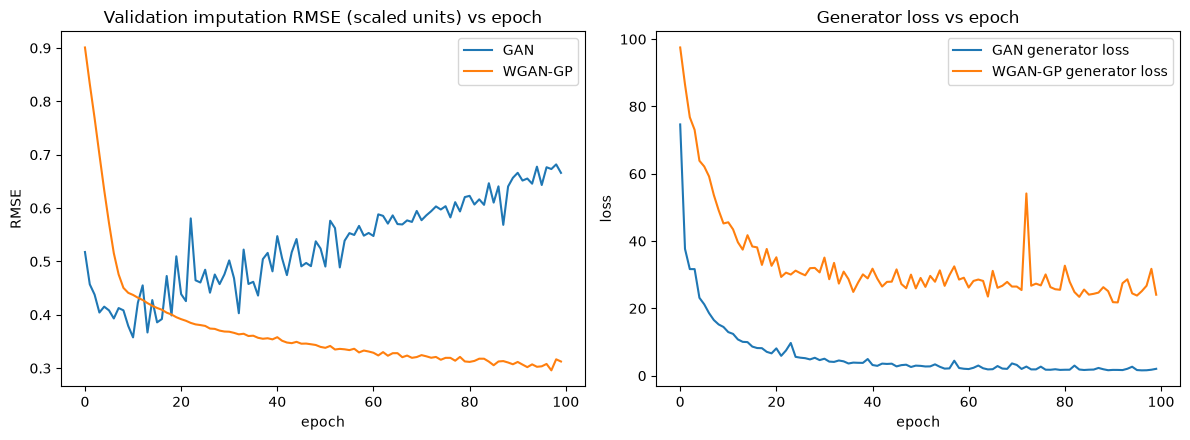

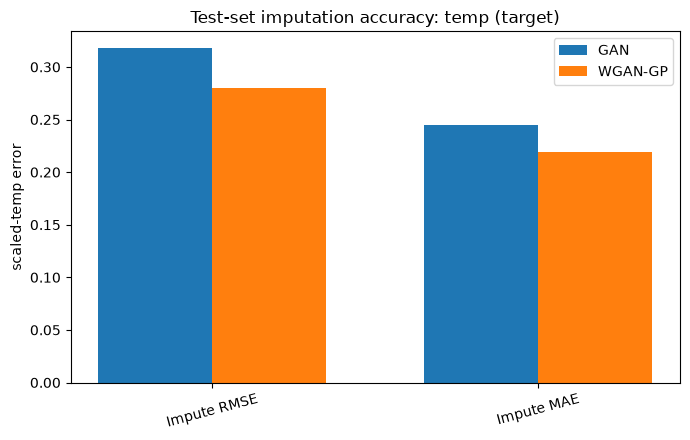

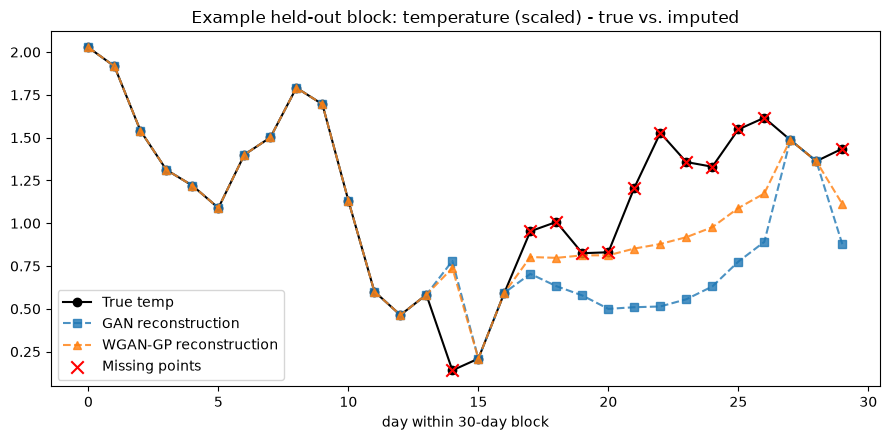

In [10]:
# ----------------------------------------------------------------------
# Plots
# ----------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(hist_gan["val_impute_rmse"], label="GAN")
axes[0].plot(hist_wgan["val_impute_rmse"], label="WGAN-GP")
axes[0].set_title("Validation imputation RMSE (scaled units) vs epoch")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("RMSE"); axes[0].legend()

axes[1].plot(hist_gan["g_loss"], label="GAN generator loss")
axes[1].plot(hist_wgan["g_loss"], label="WGAN-GP generator loss")
axes[1].set_title("Generator loss vs epoch")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("loss"); axes[1].legend()
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/shared_models_training_curves.png", dpi=140)
plt.show()

# bar chart of test-set metrics (temp only, most interpretable)
fig, ax = plt.subplots(figsize=(7, 4.5))
labels = ["Impute RMSE", "Impute MAE"]
gan_vals = [metrics_gan["impute_rmse_temp"], metrics_gan["impute_mae_temp"]]
wgan_vals = [metrics_wgan["impute_rmse_temp"], metrics_wgan["impute_mae_temp"]]
x = np.arange(len(labels)); w = 0.35
ax.bar(x - w / 2, gan_vals, w, label="GAN")
ax.bar(x + w / 2, wgan_vals, w, label="WGAN-GP")
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=15)
ax.set_ylabel("scaled-temp error"); ax.set_title("Test-set imputation accuracy: temp (target)")
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/shared_models_imputation_accuracy.png", dpi=140)
plt.show()

# example block: true vs GAN-imputed vs WGAN-imputed temp trajectory
t = FEATURES.index(TARGET)
example_block = 0
fig, ax = plt.subplots(figsize=(9, 4.5))
days = np.arange(BLOCK_LEN)
ax.plot(days, true_test[example_block, :, t], "o-", label="True temp", color="black")
ax.plot(days, xhat_gan[example_block, :, t], "s--", label="GAN reconstruction", alpha=0.8)
ax.plot(days, xhat_wgan[example_block, :, t], "^--", label="WGAN-GP reconstruction", alpha=0.8)
miss_days = np.where(test_input[example_block, :, len(FEATURES) + t] == 1)[0]
ax.scatter(miss_days, true_test[example_block, miss_days, t], color="red", zorder=5,
           label="Missing points", marker="x", s=80)
ax.set_title("Example held-out block: temperature (scaled) - true vs. imputed")
ax.set_xlabel("day within 30-day block"); ax.legend()
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/shared_models_imputation_example.png", dpi=140)
plt.show()

### 6.6 Run summary

In [11]:
# ----------------------------------------------------------------------
# Save run summary
# ----------------------------------------------------------------------
summary = {
    "n_rows": int(len(df)),
    "n_blocks_total": int(n_blocks),
    "n_train_blocks": int(len(tr_idx)),
    "n_val_blocks": int(len(val_idx)),
    "n_test_blocks": int(len(te_idx)),
    "overall_injected_missing_rate": float(overall_missing_rate),
    "gan_hparams": {"epochs": 100, "batch_size": 128, "g_lr": 1e-3, "d_lr": 1e-3, "recon_weight": 100.0},
    "wgan_hparams": {"epochs": 100, "batch_size": 128, "g_lr": 1e-4, "c_lr": 1e-4,
                      "recon_weight": 100.0, "n_critic": 5, "gp_weight": 10.0},
    "metrics": {
        "GAN": {k: float(v) for k, v in metrics_gan.items()},
        "WGAN_GP": {k: float(v) for k, v in metrics_wgan.items()},
    },
}
with open(f"{OUT_DIR}/run_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("\nDone. Outputs written to", OUT_DIR)


Done. Outputs written to outputs


## 7. Simple GAN: separate imputation and forecasting networks

The Simple GAN trains one network per task, on the same data and missingness as the shared models (seed 42, the same 30-day blocks and split).

In [12]:
import os, json, numpy as np, pandas as pd, tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, Model
from sklearn.preprocessing import StandardScaler

FEATURES = ["temp", "surface_pressure", "total_precipitation_sum",
            "dewpoint_temperature_2m", "u_component_of_wind_10m", "v_component_of_wind_10m"]
TARGET, T = "temp", 0            # T = column index of temp
SEED = 42
DATA_PATH = "data/era5_chennai_1950_2025.csv"
OUT_DIR = "outputs"
tf.keras.utils.set_random_seed(SEED)  # seeds Python, NumPy and TensorFlow, including the Keras weight initialisation

df = pd.read_csv(DATA_PATH)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)[["date"] + FEATURES]
print("Loaded:", df.shape)
bce = tf.keras.losses.BinaryCrossentropy(from_logits=False)

Loaded: (27757, 7)


### 7.1 Imputation GAN

The same GAIN-style objective, architecture and settings as the Shared GAN (Section 4), trained as a separate network. Its LSTM layers use the standard kernels (cuDNN on a GPU). The best checkpoint is chosen on the validation temperature imputation RMSE. The metrics are those of Section 6.4.

Injected missing rate: 18.5%


[GAN-imp] ep   0  D=0.6708  G=74.6634  val_temp_RMSE=0.5177


[GAN-imp] ep  10  D=0.3609  G=12.9602  val_temp_RMSE=0.3577


[GAN-imp] ep  20  D=0.1635  G=8.1185  val_temp_RMSE=0.4387


[GAN-imp] ep  30  D=0.0611  G=5.0110  val_temp_RMSE=0.5047


...

[GAN-imp] ep  70  D=0.0049  G=2.9574  val_temp_RMSE=0.5762


[GAN-imp] ep  80  D=0.0034  G=1.7475  val_temp_RMSE=0.6299


[GAN-imp] ep  90  D=0.0026  G=2.3216  val_temp_RMSE=0.6774


[GAN-imp] ep  99  D=0.0020  G=1.8082  val_temp_RMSE=0.6864
Restored best val temp RMSE: 0.3577


                     impute_rmse_temp  impute_mae_temp  impute_rmse_allfeat  \
GAN_imputation_only             0.318           0.2451                0.835   

                     impute_mae_allfeat  
GAN_imputation_only              0.4357  


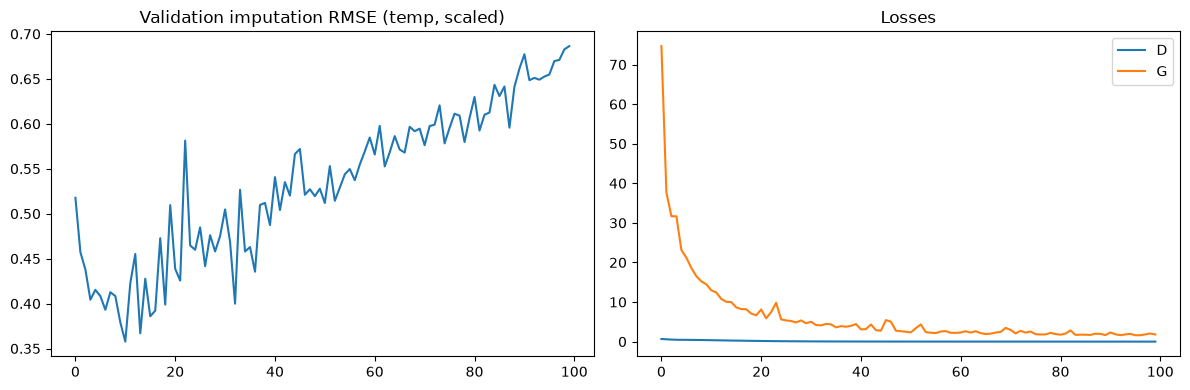

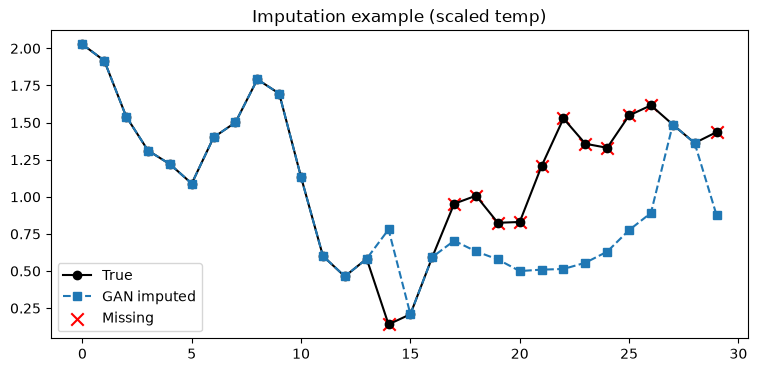

In [13]:
BLOCK_LEN = 30
EPOCHS, BATCH, LR, REC_W = 100, 128, 1e-3, 100.0
F = len(FEATURES)

# ---------- data: identical to the shared-model notebook ----------
nb_total = len(df) // BLOCK_LEN
n_tr, n_va = int(nb_total * 0.70), int(nb_total * 0.15)
tr_idx = np.arange(n_tr); va_idx = np.arange(n_tr, n_tr + n_va); te_idx = np.arange(n_tr + n_va, nb_total)
n_train_rows = n_tr * BLOCK_LEN

scaler_i = StandardScaler().fit(df.loc[:n_train_rows - 1, FEATURES])   # train rows only
scaled = scaler_i.transform(df[FEATURES]).astype(np.float32)

def inject_missing(n, f, rng, random_frac=0.10, block_frac=0.10, block_len_range=(3, 10)):
    miss = np.zeros((n, f), bool)
    for c in range(f):
        miss[rng.choice(n, int(n * random_frac), replace=False), c] = True
        placed, guard = 0, 0
        while placed < int(n * block_frac) and guard < 2000:
            guard += 1
            L = rng.integers(block_len_range[0], block_len_range[1] + 1)
            s = rng.integers(0, max(1, n - L)); e = min(n, s + L)
            miss[s:e, c] = True; placed += e - s
    return miss

rng = np.random.default_rng(SEED)
miss = inject_missing(len(scaled), F, rng)
print(f"Injected missing rate: {miss.mean():.1%}")

use = nb_total * BLOCK_LEN
true_b = scaled[:use].reshape(nb_total, BLOCK_LEN, F)
mask_b = miss[:use].reshape(nb_total, BLOCK_LEN, F).astype(np.float32)   # 1 = missing
obs_b = true_b * (1 - mask_b)                                             # zero-filled
inp_b = np.concatenate([obs_b, mask_b], -1).astype(np.float32)

train_in, val_in, test_in = inp_b[tr_idx], inp_b[va_idx], inp_b[te_idx]
true_tr, true_va, true_te = true_b[tr_idx], true_b[va_idx], true_b[te_idx]

# ---------- models ----------
def build_G():
    i = layers.Input((BLOCK_LEN, 2 * F))
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(i)
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
    x = layers.TimeDistributed(layers.Dense(64, activation="relu"))(x)
    return Model(i, layers.TimeDistributed(layers.Dense(F))(x), name="G_imp")

def build_D():
    i = layers.Input((BLOCK_LEN, 2 * F))
    x = layers.Bidirectional(layers.LSTM(48, return_sequences=True))(i)
    x = layers.TimeDistributed(layers.Dense(48, activation="relu"))(x)
    return Model(i, layers.TimeDistributed(layers.Dense(F, activation="sigmoid"))(x), name="D_imp")

G, D = build_G(), build_D()
g_opt = tf.keras.optimizers.Adam(LR, beta_1=0.5)
d_opt = tf.keras.optimizers.Adam(LR, beta_1=0.5)
blend = lambda x0, m, xb: x0 + m * (xb - x0)     # keep observed, fill missing with G output

@tf.function
def train_step(xb, mb):
    obs_mask = 1.0 - mb
    inp = tf.concat([xb, mb], -1)
    with tf.GradientTape() as t:                                   # discriminator
        x_hat = blend(xb, mb, G(inp, training=True))
        d_loss = bce(obs_mask, D(tf.concat([x_hat, obs_mask], -1), training=True))
    d_opt.apply_gradients(zip(t.gradient(d_loss, D.trainable_variables), D.trainable_variables))
    with tf.GradientTape() as t:                                   # generator
        x_bar = G(inp, training=True)
        x_hat = blend(xb, mb, x_bar)
        d_prob = D(tf.concat([x_hat, obs_mask], -1), training=False)
        g_adv = -tf.reduce_mean(mb * tf.math.log(d_prob + 1e-7))
        g_rec = tf.reduce_sum(obs_mask * tf.square(xb - x_bar)) / (tf.reduce_sum(obs_mask) + 1e-7)
        g_loss = g_adv + REC_W * g_rec
    g_opt.apply_gradients(zip(t.gradient(g_loss, G.trainable_variables), G.trainable_variables))
    return d_loss, g_loss

def impute_metrics(inp, true):
    obs, m = inp[..., :F], inp[..., F:]
    x_hat = obs + m * (G(inp, training=False).numpy() - obs)
    err = (x_hat - true) * m
    e_t, m_t = err[..., T], m[..., T]
    return {
        "impute_rmse_temp": np.sqrt((e_t**2).sum() / m_t.sum()),
        "impute_mae_temp": np.abs(e_t).sum() / m_t.sum(),
        "impute_rmse_allfeat": np.sqrt((err**2).sum() / m.sum()),
        "impute_mae_allfeat": np.abs(err).sum() / m.sum(),
    }, x_hat

# ---------- train (best checkpoint on validation imputation RMSE) ----------
ds = (tf.data.Dataset.from_tensor_slices((train_in[..., :F], train_in[..., F:]))
      .shuffle(len(train_in)).batch(BATCH).prefetch(tf.data.AUTOTUNE))
hist, best, best_w = {"d": [], "g": [], "val_rmse": []}, np.inf, None
t0 = time.time()
for ep in range(EPOCHS):
    dl, gl = [], []
    for xb, mb in ds:
        d, g = train_step(xb, mb); dl.append(float(d)); gl.append(float(g))
    v = impute_metrics(val_in, true_va)[0]["impute_rmse_temp"]
    hist["d"].append(np.mean(dl)); hist["g"].append(np.mean(gl)); hist["val_rmse"].append(v)
    if v < best: best, best_w = v, G.get_weights()
    if ep % 10 == 0 or ep == EPOCHS - 1:
        print(f"[GAN-imp] ep {ep:3d}  D={np.mean(dl):.4f}  G={np.mean(gl):.4f}  val_temp_RMSE={v:.4f}")
G.set_weights(best_w); print("Restored best val temp RMSE:", round(best, 4))
train_time["Simple GAN (imputation)"] = time.time() - t0

# ---------- test ----------
m_imp, xhat_imp = impute_metrics(test_in, true_te)
res_imp = pd.DataFrame({"GAN_imputation_only": m_imp}).T
print(res_imp.round(4)); res_imp.to_csv(f"{OUT_DIR}/gan_imputation_only_metrics.csv")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(hist["val_rmse"]); ax[0].set_title("Validation imputation RMSE (temp, scaled)")
ax[1].plot(hist["d"], label="D"); ax[1].plot(hist["g"], label="G"); ax[1].legend(); ax[1].set_title("Losses")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/gan_imputation_curves.png", dpi=140); plt.show()

b = 0; miss_d = np.where(test_in[b, :, F + T] == 1)[0]
plt.figure(figsize=(9, 4))
plt.plot(true_te[b, :, T], "ko-", label="True"); plt.plot(xhat_imp[b, :, T], "s--", label="GAN imputed")
plt.scatter(miss_d, true_te[b, miss_d, T], c="r", marker="x", s=80, label="Missing")
plt.legend(); plt.title("Imputation example (scaled temp)")
plt.savefig(f"{OUT_DIR}/gan_imputation_example.png", dpi=140)
plt.show()

### 7.2 Forecasting GAN

A conditional GAN that predicts the next 7 days of temperature from the previous 30 days of all six variables.

* **Windows:** 30-day context → 7-day target, built separately inside the training, validation and test periods (stride 1 for training, 7 for validation and testing). The periods use the same 30-day-block boundaries as the imputation experiments, and the scaler is fitted on the training rows.
* **Generator:** LSTM(64) → LSTM(64), concatenated with a 16-dimensional noise vector $z$, then Dense(64, ReLU) and Dense(7).
* **Discriminator:** one LSTM(48) over the context and one over the 7-day sequence, concatenated, then Dense(48, ReLU) and a sigmoid output.
* **Losses:** discriminator: binary cross-entropy, real vs. generated 7-day sequences for the same context. Generator: binary cross-entropy + 100 × mean squared error to the true 7-day sequence.
* **Optimisation:** Adam (learning rate $10^{-3}$, $\beta_1 = 0.5$), 60 epochs, batch size 128; best checkpoint on the validation RMSE.
* **Inference:** deterministic, with $z = 0$.
* **Metrics** (`fc_metrics`): `RMSE` and `MAE` of the temperature forecasts, the same divided by the training standard deviation of temperature (`RMSE_scaled`, `MAE_scaled`), and $R^2$, over all test windows and lead days; RMSE by lead day.

windows  train/val/test: 19374 587 596


[GAN-fc] ep   0  D=1.3503  G=26.3939  val_RMSE=1.172


[GAN-fc] ep  10  D=0.9355  G=11.6447  val_RMSE=1.000


[GAN-fc] ep  20  D=1.0283  G=9.1347  val_RMSE=1.064


[GAN-fc] ep  30  D=1.0732  G=6.7281  val_RMSE=1.163


[GAN-fc] ep  40  D=1.1048  G=5.1630  val_RMSE=1.201


[GAN-fc] ep  50  D=1.1505  G=4.3880  val_RMSE=1.195


[GAN-fc] ep  59  D=1.1649  G=4.0349  val_RMSE=1.198
Restored best val RMSE: 0.961



Test: 7-day-ahead forecast from 30-day context
                        RMSE     MAE      R2  RMSE_scaled  MAE_scaled
GAN_forecasting_only  0.9348  0.7026  0.8548       0.3388      0.2546
Per-lead-day RMSE: [0.607 0.788 0.844 0.979 1.043 1.096 1.081]


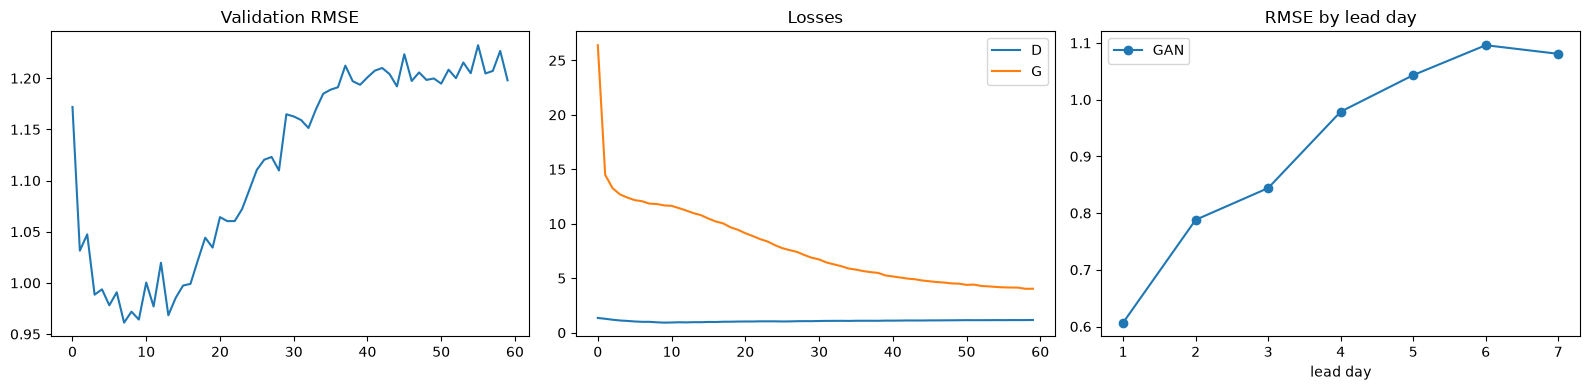

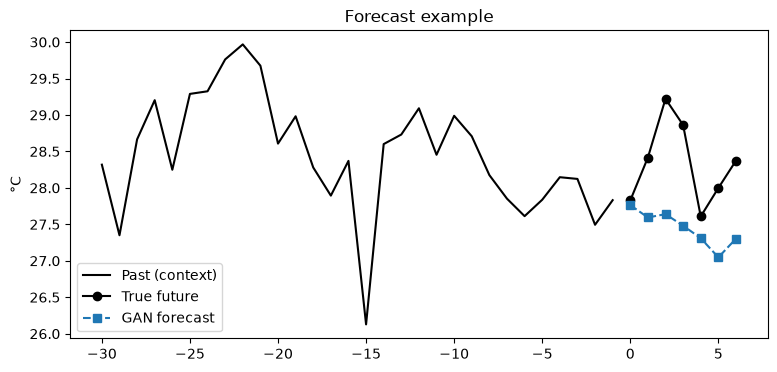

In [14]:
CONTEXT, HORIZON, NOISE = 30, 7, 16
EPOCHS_F, BATCH_F, LR_F, REC_W_F = 60, 128, 1e-3, 100.0

# ---------- chronological split at the same 30-day-block boundaries as the imputation experiments;
# ---------- scaler on TRAIN only
n = len(df); tr_end, va_end = n_tr * BLOCK_LEN, (n_tr + n_va) * BLOCK_LEN
scaler_f = StandardScaler().fit(df.loc[:tr_end - 1, FEATURES])
sc = scaler_f.transform(df[FEATURES]).astype(np.float32)
mu, sig = scaler_f.mean_[T], scaler_f.scale_[T]

def make_windows(arr, stride):
    idx = range(0, len(arr) - CONTEXT - HORIZON + 1, stride)
    X = np.stack([arr[i:i + CONTEXT] for i in idx])                       # (N, CONTEXT, F)
    Y = np.stack([arr[i + CONTEXT:i + CONTEXT + HORIZON, T] for i in idx])[..., None]  # (N, H, 1)
    return X, Y

Xtr, Ytr = make_windows(sc[:tr_end], 1)          # windows never cross split boundaries
Xva, Yva = make_windows(sc[tr_end:va_end], HORIZON)
Xte, Yte = make_windows(sc[va_end:], HORIZON)
print("windows  train/val/test:", len(Xtr), len(Xva), len(Xte))

# ---------- models ----------
def build_Gf():
    x_in = layers.Input((CONTEXT, F)); z_in = layers.Input((NOISE,))
    h = layers.LSTM(64, return_sequences=True)(x_in)
    h = layers.LSTM(64)(h)
    h = layers.Concatenate()([h, z_in])
    h = layers.Dense(64, activation="relu")(h)
    out = layers.Reshape((HORIZON, 1))(layers.Dense(HORIZON)(h))
    return Model([x_in, z_in], out, name="G_fc")

def build_Df():
    x_in = layers.Input((CONTEXT, F)); y_in = layers.Input((HORIZON, 1))
    hx = layers.LSTM(48)(x_in); hy = layers.LSTM(48)(y_in)
    h = layers.Dense(48, activation="relu")(layers.Concatenate()([hx, hy]))
    return Model([x_in, y_in], layers.Dense(1, activation="sigmoid")(h), name="D_fc")

Gf, Df = build_Gf(), build_Df()
gf_opt = tf.keras.optimizers.Adam(LR_F, beta_1=0.5)
df_opt = tf.keras.optimizers.Adam(LR_F, beta_1=0.5)

@tf.function
def train_step_f(xb, yb):
    z = tf.random.normal([tf.shape(xb)[0], NOISE])
    with tf.GradientTape() as t:
        y_fake = Gf([xb, z], training=True)
        d_real, d_fake = Df([xb, yb], training=True), Df([xb, y_fake], training=True)
        d_loss = bce(tf.ones_like(d_real), d_real) + bce(tf.zeros_like(d_fake), d_fake)
    df_opt.apply_gradients(zip(t.gradient(d_loss, Df.trainable_variables), Df.trainable_variables))
    with tf.GradientTape() as t:
        y_fake = Gf([xb, z], training=True)
        d_fake = Df([xb, y_fake], training=False)
        g_adv = bce(tf.ones_like(d_fake), d_fake)
        g_rec = tf.reduce_mean(tf.square(yb - y_fake))
        g_loss = g_adv + REC_W_F * g_rec
    gf_opt.apply_gradients(zip(t.gradient(g_loss, Gf.trainable_variables), Gf.trainable_variables))
    return d_loss, g_loss

def predict(X):   # deterministic inference: z = 0
    return Gf([X, np.zeros((len(X), NOISE), np.float32)], training=False).numpy()

def fc_metrics(pred, Y):
    p, y = pred[..., 0] * sig + mu, Y[..., 0] * sig + mu          # back to °C
    rmse, mae = np.sqrt(np.mean((p - y) ** 2)), np.mean(np.abs(p - y))
    r2 = 1 - np.sum((p - y) ** 2) / np.sum((y - y.mean()) ** 2)
    return {"RMSE": rmse, "MAE": mae, "R2": r2,
            "RMSE_scaled": rmse / sig, "MAE_scaled": mae / sig}, np.sqrt(np.mean((p - y) ** 2, 0))

# ---------- train (best checkpoint on validation RMSE) ----------
ds = (tf.data.Dataset.from_tensor_slices((Xtr, Ytr)).shuffle(len(Xtr))
      .batch(BATCH_F).prefetch(tf.data.AUTOTUNE))
hist_f, best, best_w = {"d": [], "g": [], "val_rmse": []}, np.inf, None
t0 = time.time()
for ep in range(EPOCHS_F):
    dl, gl = [], []
    for xb, yb in ds:
        d, g = train_step_f(xb, yb); dl.append(float(d)); gl.append(float(g))
    v = fc_metrics(predict(Xva), Yva)[0]["RMSE"]
    hist_f["d"].append(np.mean(dl)); hist_f["g"].append(np.mean(gl)); hist_f["val_rmse"].append(v)
    if v < best: best, best_w = v, Gf.get_weights()
    if ep % 10 == 0 or ep == EPOCHS_F - 1:
        print(f"[GAN-fc] ep {ep:3d}  D={np.mean(dl):.4f}  G={np.mean(gl):.4f}  val_RMSE={v:.3f}")
Gf.set_weights(best_w); print("Restored best val RMSE:", round(best, 3))
train_time["Simple GAN (forecasting)"] = time.time() - t0

# ---------- test ----------
pred_te = predict(Xte)
m_fc, per_day = fc_metrics(pred_te, Yte)
res_fc = pd.DataFrame({"GAN_forecasting_only": m_fc}).T
print(f"\nTest: {HORIZON}-day-ahead forecast from {CONTEXT}-day context")
print(res_fc.round(4)); res_fc.to_csv(f"{OUT_DIR}/gan_forecasting_only_metrics.csv")
print("Per-lead-day RMSE:", np.round(per_day, 3))

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].plot(hist_f["val_rmse"]); ax[0].set_title("Validation RMSE")
ax[1].plot(hist_f["d"], label="D"); ax[1].plot(hist_f["g"], label="G"); ax[1].legend(); ax[1].set_title("Losses")
ax[2].plot(range(1, HORIZON + 1), per_day, "o-", label="GAN")
ax[2].set_xlabel("lead day"); ax[2].set_title("RMSE by lead day"); ax[2].legend()
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/gan_forecasting_curves.png", dpi=140); plt.show()

k = 10; past = Xte[k, :, T] * sig + mu
plt.figure(figsize=(9, 4))
plt.plot(range(-CONTEXT, 0), past, "k-", label="Past (context)")
plt.plot(range(HORIZON), Yte[k, :, 0] * sig + mu, "ko-", label="True future")
plt.plot(range(HORIZON), pred_te[k, :, 0] * sig + mu, "s--", label="GAN forecast")
plt.legend(); plt.ylabel("°C"); plt.title("Forecast example")
plt.savefig(f"{OUT_DIR}/gan_forecasting_example.png", dpi=140)
plt.show()

## 8. Shared models as forecasters

The shared generators were trained only for imputation. To use them as forecasters, each test window of Section 7.2 becomes a 30-day block that ends on the window's last target day. The first 23 days of the block are observed; the last 7 days are masked for every variable (values zero-filled, indicator 1). The generator fills the masked days, and its temperature values for those days are the 7-day forecast.

The targets are exactly the test targets of Section 7.2 (`Yte`), and the scores use the same `fc_metrics`. The shared generators see 23 days of context; the Simple GAN forecaster sees 30.

In [15]:
# Same scaled data as the shared models (Section 6.1): one split and one scaler for all experiments
assert np.allclose(sc, df_scaled[FEATURES].to_numpy(dtype=np.float32), atol=1e-5)

CONTEXT_SHARED = BLOCK_LEN - HORIZON                                    # 23 observed + 7 masked days = 30
first_target_rows = va_end + np.arange(len(Xte)) * HORIZON + CONTEXT    # first forecast day of each test window
assert np.allclose(np.stack([sc[r:r + HORIZON, T] for r in first_target_rows])[..., None], Yte)


def shared_forecast(G_shared):
    """7-day temperature forecast from a shared generator: mask the last HORIZON days of a 30-day block."""
    x = np.stack([sc[r - CONTEXT_SHARED:r + HORIZON] for r in first_target_rows])     # (N, 30, F)
    m = np.zeros_like(x)
    m[:, CONTEXT_SHARED:, :] = 1.0                                                  # 1 = missing (the future)
    x_bar = G_shared(np.concatenate([x * (1.0 - m), m], axis=-1), training=False).numpy()
    return x_bar[:, CONTEXT_SHARED:, T:T + 1]                                       # (N, HORIZON, 1)


fc_shared, per_day_shared = {}, {}
for name, G_shared in {"Shared GAN": G_gan, "Shared WGAN-GP": G_wgan}.items():
    fc_shared[name], per_day_shared[name] = fc_metrics(shared_forecast(G_shared), Yte)

res_fc_all = pd.DataFrame({**fc_shared, "Simple GAN (forecasting only)": m_fc}).T
print(f"Test: {HORIZON}-day-ahead temperature forecasts, {len(Yte)} windows")
print(res_fc_all.round(4)); res_fc_all.to_csv(f"{OUT_DIR}/forecast_comparison_metrics.csv")
print("Per-lead-day RMSE:")
for name, rmse in {**per_day_shared, "Simple GAN (forecasting only)": per_day}.items():
    print(f"  {name:30s} {np.round(rmse, 3)}")

Test: 7-day-ahead temperature forecasts, 596 windows
                                 RMSE     MAE      R2  RMSE_scaled  MAE_scaled
Shared GAN                     1.7635  1.4335  0.4834       0.6392      0.5195
Shared WGAN-GP                 1.3200  1.0537  0.7106       0.4784      0.3819
Simple GAN (forecasting only)  0.9348  0.7026  0.8548       0.3388      0.2546
Per-lead-day RMSE:
  Shared GAN                     [1.133 1.437 1.691 1.857 1.97  2.008 2.05 ]
  Shared WGAN-GP                 [0.948 1.116 1.256 1.363 1.453 1.494 1.507]
  Simple GAN (forecasting only)  [0.607 0.788 0.844 0.979 1.043 1.096 1.081]


## 9. Comparison: accuracy, parameters and training time

* **Accuracy:** imputation metrics from Sections 6.4 and 7.1 (scaled units, removed test positions); forecasting metrics from Sections 7.2 and 8 (all test windows and lead days).
* **Parameters:** trainable parameters of the generator(s) needed to perform both tasks, and the total including the discriminator(s) or critic used during training.
* **Training time:** wall-clock time of the training loops on the hardware of this run (printed below). The shared approach trains one model for both tasks; the Simple GAN approach trains two.

In [16]:
IMP_KEYS = ["impute_rmse_temp", "impute_mae_temp", "impute_rmse_allfeat", "impute_mae_allfeat"]
FC_KEYS = ["RMSE", "MAE", "R2", "RMSE_scaled", "MAE_scaled"]
imputation = {"Shared GAN": metrics_gan, "Shared WGAN-GP": metrics_wgan, "Simple GAN": m_imp}
forecasting = {"Shared GAN": fc_shared["Shared GAN"], "Shared WGAN-GP": fc_shared["Shared WGAN-GP"], "Simple GAN": m_fc}
accuracy = pd.DataFrame({name: {**{k: float(imputation[name][k]) for k in IMP_KEYS},
                                **{f"forecast_{k}": float(forecasting[name][k]) for k in FC_KEYS}}
                         for name in imputation}).T

n_params = lambda *models: int(sum(m.count_params() for m in models))
efficiency = pd.DataFrame({
    "Shared GAN": {"generators for both tasks": 1, "generator parameters": n_params(G_gan),
                   "parameters incl. discriminator/critic": n_params(G_gan, D_gan),
                   "training time (min)": train_time["Shared GAN"] / 60},
    "Shared WGAN-GP": {"generators for both tasks": 1, "generator parameters": n_params(G_wgan),
                       "parameters incl. discriminator/critic": n_params(G_wgan, C_wgan),
                       "training time (min)": train_time["Shared WGAN-GP"] / 60},
    "Simple GAN": {"generators for both tasks": 2, "generator parameters": n_params(G, Gf),
                   "parameters incl. discriminator/critic": n_params(G, D, Gf, Df),
                   "training time (min)": (train_time["Simple GAN (imputation)"]
                                           + train_time["Simple GAN (forecasting)"]) / 60},
}).T.astype({"generators for both tasks": int, "generator parameters": int,
             "parameters incl. discriminator/critic": int})

gpus = tf.config.list_physical_devices("GPU")
print("Hardware:", ", ".join(g.name for g in gpus) if gpus else "CPU only", "| TensorFlow", tf.__version__)
print(f"Training standard deviation of temperature (RMSE_scaled = RMSE / this value): {scaler.scale_[FEATURES.index(TARGET)]:.3f}")
print("Simple GAN training time by task (min):",
      {k: round(v / 60, 2) for k, v in train_time.items() if k.startswith("Simple GAN")})
print("\n===== ACCURACY ON BOTH TASKS (test set) =====")
print(accuracy.round(4))
print("\n===== PARAMETERS AND TRAINING TIME =====")
print(efficiency.round(2))
accuracy.to_csv(f"{OUT_DIR}/comparison_accuracy.csv")
efficiency.to_csv(f"{OUT_DIR}/comparison_efficiency.csv")

Hardware: CPU only | TensorFlow 2.21.0
Training standard deviation of temperature (RMSE_scaled = RMSE / this value): 2.759
Simple GAN training time by task (min): {'Simple GAN (imputation)': 2.62, 'Simple GAN (forecasting)': 9.3}

===== ACCURACY ON BOTH TASKS (test set) =====
                impute_rmse_temp  impute_mae_temp  impute_rmse_allfeat  \
Shared GAN                0.3180           0.2451               0.8350   
Shared WGAN-GP            0.2797           0.2195               0.7847   
Simple GAN                0.3180           0.2451               0.8350   

                impute_mae_allfeat  forecast_RMSE  forecast_MAE  forecast_R2  \
Shared GAN                  0.4357         1.7635        1.4335       0.4834   
Shared WGAN-GP              0.3781         1.3200        1.0537       0.7106   
Simple GAN                  0.4357         0.9348        0.7026       0.8548   

                forecast_RMSE_scaled  forecast_MAE_scaled  
Shared GAN                    0.6392         

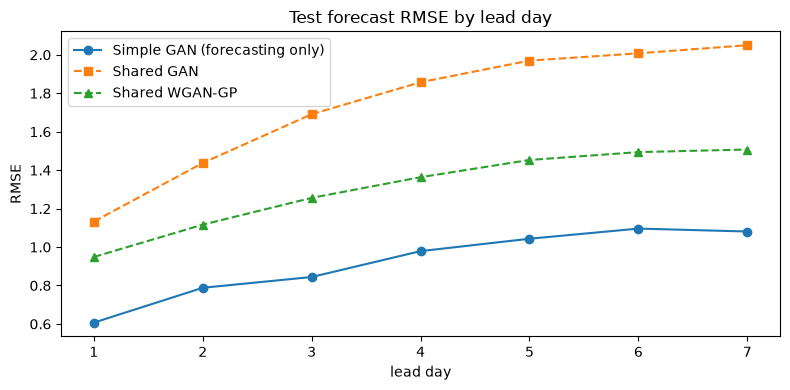

In [17]:
plt.figure(figsize=(8, 4))
leads = range(1, HORIZON + 1)
plt.plot(leads, per_day, "o-", label="Simple GAN (forecasting only)")
plt.plot(leads, per_day_shared["Shared GAN"], "s--", label="Shared GAN")
plt.plot(leads, per_day_shared["Shared WGAN-GP"], "^--", label="Shared WGAN-GP")
plt.xlabel("lead day"); plt.ylabel("RMSE"); plt.title("Test forecast RMSE by lead day"); plt.legend()
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/forecast_rmse_by_lead_day.png", dpi=140); plt.show()

## 10. Temporal maps of the imputed temperatures

Each map covers the test period (2014–2025): one row per year, one column per day of the year. Only the days whose temperature was removed are coloured. The first map shows the true and the imputed temperatures, the second the imputation error (imputed − true) of each model.

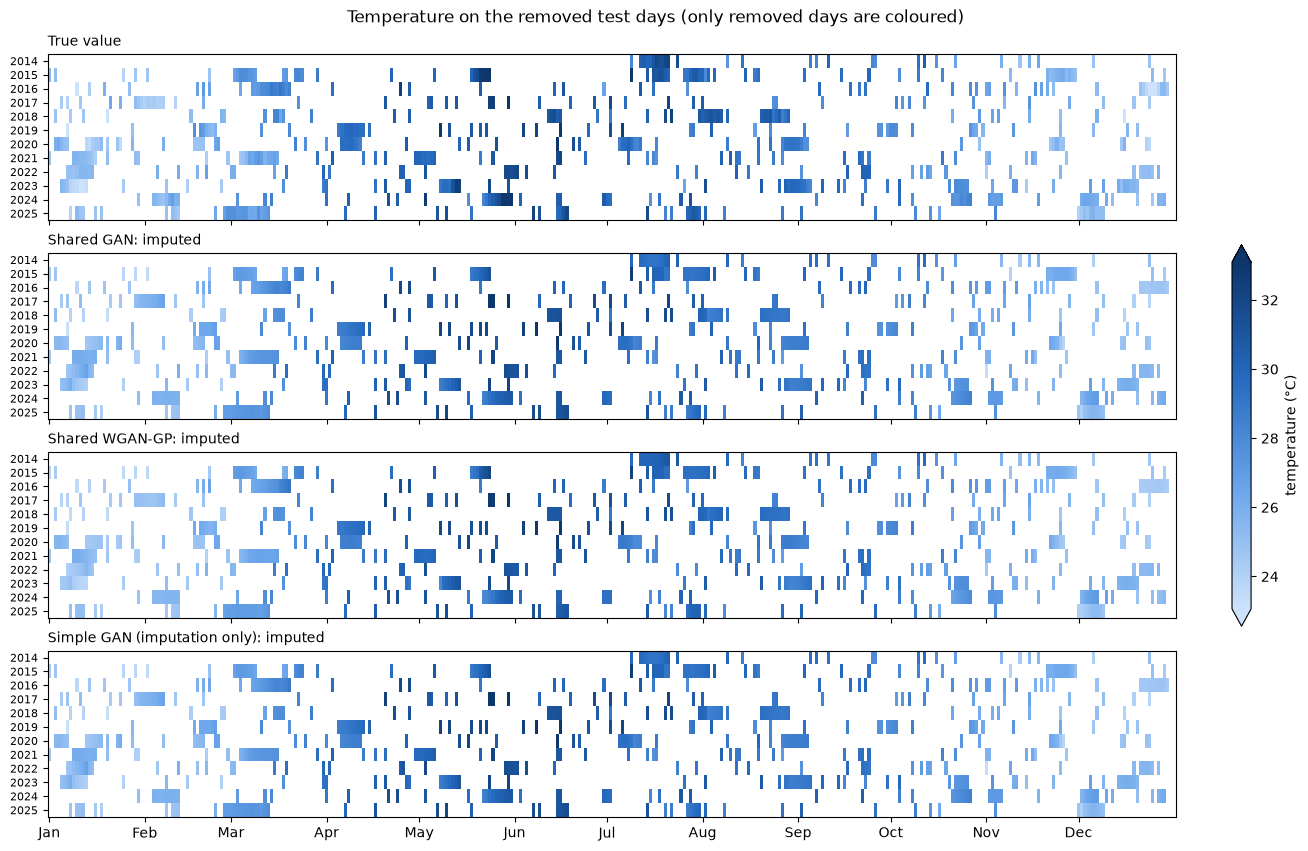

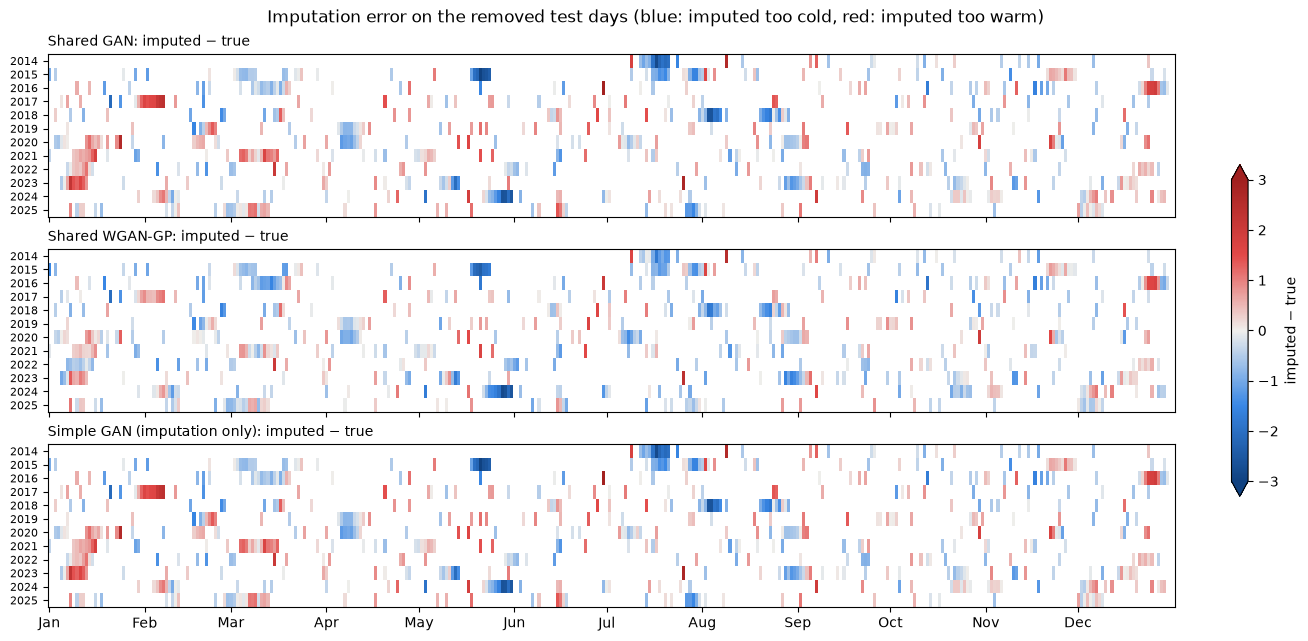

In [18]:
import matplotlib.colors as mcolors

t_idx = FEATURES.index(TARGET)
to_degc = lambda z: z * scaler.scale_[t_idx] + scaler.mean_[t_idx]
rows = (te_idx[:, None] * BLOCK_LEN + np.arange(BLOCK_LEN)[None, :]).ravel()    # data rows of the test blocks
dates = pd.DatetimeIndex(df["date"].iloc[rows])
removed = test_input[..., len(FEATURES) + t_idx].ravel() == 1
series = {"True value": to_degc(true_test[..., t_idx].ravel()),
          "Shared GAN": to_degc(xhat_gan[..., t_idx].ravel()),
          "Shared WGAN-GP": to_degc(xhat_wgan[..., t_idx].ravel()),
          "Simple GAN (imputation only)": to_degc(xhat_imp[..., t_idx].ravel())}
years = np.arange(dates.year.min(), dates.year.max() + 1)
month_starts = pd.date_range("2001-01-01", periods=12, freq="MS")


def calendar(values):
    """(years x 366) grid holding the value of each removed test day; NaN elsewhere."""
    grid = np.full((len(years), 366), np.nan)
    grid[dates.year[removed] - years[0], dates.dayofyear[removed] - 1] = values[removed]
    return np.ma.masked_invalid(grid)


def calendar_axes(ax, title):
    ax.set_title(title, loc="left", fontsize=10)
    ax.set_xticks(month_starts.dayofyear - 1, month_starts.strftime("%b"))
    ax.set_yticks(np.arange(len(years)), years, fontsize=8)


seq = mcolors.LinearSegmentedColormap.from_list("temperature", ["#cde2fb", "#6da7ec", "#256abf", "#0d366b"])
seq.set_bad("white")
vmin, vmax = np.percentile(series["True value"][removed], [1, 99])
fig, axes = plt.subplots(len(series), 1, figsize=(13, 2.1 * len(series)), sharex=True, constrained_layout=True)
for ax, (name, values) in zip(axes, series.items()):
    im = ax.imshow(calendar(values), aspect="auto", cmap=seq, vmin=vmin, vmax=vmax, interpolation="nearest")
    calendar_axes(ax, name if name == "True value" else f"{name}: imputed")
fig.colorbar(im, ax=axes, shrink=0.5, extend="both", label="temperature (°C)")
fig.suptitle("Temperature on the removed test days (only removed days are coloured)")
plt.savefig(f"{OUT_DIR}/temporal_map_imputed_temperature.png", dpi=140)
plt.show()

div = mcolors.LinearSegmentedColormap.from_list("error", ["#104281", "#3987e5", "#f0efec", "#e34948", "#a1201f"])
div.set_bad("white")
fig, axes = plt.subplots(len(series) - 1, 1, figsize=(13, 2.1 * (len(series) - 1)), sharex=True,
                         constrained_layout=True)
for ax, name in zip(axes, list(series)[1:]):
    im = ax.imshow(calendar(series[name] - series["True value"]), aspect="auto", cmap=div, vmin=-3, vmax=3,
                   interpolation="nearest")
    calendar_axes(ax, f"{name}: imputed − true")
fig.colorbar(im, ax=axes, shrink=0.6, extend="both", label="imputed − true")
fig.suptitle("Imputation error on the removed test days (blue: imputed too cold, red: imputed too warm)")
plt.savefig(f"{OUT_DIR}/temporal_map_imputation_error.png", dpi=140)
plt.show()

## 11. Results

The numbers below are those of the run shown in this notebook: one run with seed 42, on a CPU with TensorFlow 2.21. The test period is 2014–2025: 140 blocks for imputation and 596 windows for forecasting. Best values are in bold.

**Imputation** (removed test positions, scaled units, lower is better)

| Model | `impute_rmse_temp` | `impute_mae_temp` | `impute_rmse_allfeat` | `impute_mae_allfeat` |
|---|---|---|---|---|
| Shared GAN | 0.3180 | 0.2451 | 0.8350 | 0.4357 |
| Shared WGAN-GP | **0.2797** | **0.2195** | **0.7847** | **0.3781** |
| Simple GAN (imputation only) | 0.3180 | 0.2451 | 0.8350 | 0.4357 |

**7-day temperature forecasting** (596 test windows)

| Model | `RMSE` | `MAE` | `R2` | `RMSE_scaled` | `MAE_scaled` |
|---|---|---|---|---|---|
| Shared GAN | 1.7635 | 1.4335 | 0.4834 | 0.6392 | 0.5195 |
| Shared WGAN-GP | 1.3200 | 1.0537 | 0.7106 | 0.4784 | 0.3819 |
| Simple GAN (forecasting only) | **0.9348** | **0.7026** | **0.8548** | **0.3388** | **0.2546** |

RMSE by lead day, from day 1 to day 7: Simple GAN 0.61 to 1.08, Shared WGAN-GP 0.95 to 1.51, Shared GAN 1.13 to 2.05 (Section 9).

**Parameters and training time**

| Approach | Generators for both tasks | Generator parameters | Parameters incl. discriminator/critic | Training time (min) |
|---|---|---|---|---|
| Shared GAN | 1 | **146,886** | **175,260** | **2.9** |
| Shared WGAN-GP | 1 | **146,886** | 193,639 | 7.8 |
| Simple GAN | 2 | 203,725 | 256,964 | 11.9 (2.6 imputation + 9.3 forecasting) |

**Summary**

* **Imputation:** the Shared WGAN-GP has the lowest error of the three models on all four metrics. Its temperature RMSE is 12 % lower (0.2797 vs. 0.3180) than that of the Shared GAN and the Simple GAN, which give identical imputation results to four decimals: they are the same network with the same objective, settings and seed.
* **Forecasting:** the Simple GAN forecaster, trained for this task, has the lowest error. The RMSE of the Shared WGAN-GP is 41 % higher (1.320 vs. 0.935), and that of the Shared GAN 89 % higher (1.764).
* **Cost:** each shared model handles both tasks with one generator of 146,886 parameters, 28 % fewer than the two generators of the Simple GAN approach (203,725), and with one training run: 2.9 min (Shared GAN) and 7.8 min (Shared WGAN-GP), against 11.9 min for the two Simple GAN networks on the same CPU.
* **Training:** the validation error of the Shared WGAN-GP reached its lowest value in the last ten of its 100 epochs (Section 6.5).
* **The claim:** in this run, the shared architecture needs fewer parameters and less training time for the two tasks, and the Shared WGAN-GP is the most accurate imputer. For forecasting, the dedicated Simple GAN forecaster is more accurate than both shared models.

## 12. Notes, changes from the original notebook, and references

**Notes**
* Every model was trained once, with seed 42. `tf.keras.utils.set_random_seed` fixes the weight initialisation and the random draws during training, so a re-run on the same machine reproduces the results. GPU kernels are not bit-for-bit deterministic, so a run on other hardware can differ slightly.
* Training times depend on the hardware; Section 9 prints the hardware of the run shown.
* Imputation metrics are in scaled units. Forecasting metrics are given unscaled (`RMSE`, `MAE`) and scaled (`RMSE_scaled`, `MAE_scaled`).
* The WGAN-GP critic uses complete training blocks, including the removed values, as real examples. This assumes that complete historical data are available for training.
* The Shared GAN and the Simple imputation GAN use the same objective, architecture, settings and seed (Sections 4 and 7.1), so they start from the same weights; they differ only in the LSTM kernel implementation. In the run shown, their imputation results are identical to four decimals.

**Changes from the original notebook (`Untitled4.ipynb`)**

The model and training code is unchanged. The changes are:

1. **Data and output paths.** The data are read from `data/era5_chennai_1950_2025.csv`, which Section 1 provides, and outputs are written to `outputs/` instead of `/content`.
2. **Figures.** `matplotlib.use("Agg")` was removed so that the figures are displayed in the notebook. The Section 6 figures are also saved to `outputs/`.
3. **Forecast metric.** The whole-block "forecast" metrics (`forecast_rmse_*`, `forecast_mae_*`) were removed from `evaluate`. They averaged the error over every point of the test blocks, including the observed points where the error is zero by construction, so they equalled the imputation error × √(missing fraction). In the original run, 0.3268 × √(702 / 4200) = 0.1336, the reported GAN `forecast_rmse_temp`. Forecasting is now evaluated on 7-day forecasts (Sections 7.2 and 8).
4. **One split.** The forecasting experiment (Section 7.2) uses the same 30-day-block boundaries and scaler as the imputation experiments, instead of a separate row-based 70/15/15 split.
5. **No baseline.** The persistence baseline was removed from Section 7.2, so that only GAN variants are compared.
6. **New sections.** Training times are recorded (`train_time`), and Sections 8–10 were added: the shared models as forecasters; the comparison of accuracy, parameters and training time; and the temporal maps.
7. **Comments.** The docstring of the model cell now states that the WGAN-GP also differs in its re-masking and feature-weighted reconstruction, and an outdated comment about `train_wgan_simple` was removed.
8. **Metric names.** `RMSE_degC` and `MAE_degC` were renamed `RMSE` and `MAE`; `impute_rmse_temp_degC` and `impute_mae_temp_degC` were removed; and the unit was removed from the error labels.
9. **Seeding.** `tf.random.set_seed(...)` was replaced by `tf.keras.utils.set_random_seed(...)` in `train_gan`, `train_wgan` and the Simple GAN setup cell. `tf.random.set_seed` alone does not fix the Keras weight initialisation, so repeated runs of the original code gave different results.

**References**
* Muñoz-Sabater, J. et al. (2021). ERA5-Land: a state-of-the-art global reanalysis dataset for land applications. *Earth System Science Data*, 13, 4349–4383.
* Gorelick, N. et al. (2017). Google Earth Engine: planetary-scale geospatial analysis for everyone. *Remote Sensing of Environment*, 202, 18–27.
* Goodfellow, I. et al. (2014). Generative adversarial nets. *Advances in Neural Information Processing Systems*, 27.
* Yoon, J., Jordon, J. & van der Schaar, M. (2018). GAIN: missing data imputation using generative adversarial nets. *ICML*, PMLR 80, 5689–5698.
* Arjovsky, M., Chintala, S. & Bottou, L. (2017). Wasserstein generative adversarial networks. *ICML*, PMLR 70, 214–223.
* Gulrajani, I. et al. (2017). Improved training of Wasserstein GANs. *Advances in Neural Information Processing Systems*, 30.
* Mirza, M. & Osindero, S. (2014). Conditional generative adversarial nets. arXiv:1411.1784.

**Data licence.** ERA5-Land is produced by ECMWF for the Copernicus Climate Change Service and distributed under the Licence to Use Copernicus Products. The extract in `data/` contains modified Copernicus Climate Change Service information (1950–2025). Neither the European Commission nor ECMWF is responsible for any use of this information.